In [8]:
import os
import sys

import pandas as pd
#import seaborn as sns
import numpy as np

import json
from pathlib import Path
from SALib.analyze import morris as morris_analyzer

import matplotlib.pyplot as plt

# Morris analysis and scaling 

Performs Morris Analysis with SALib library. The results are scaled after processing to make comparable analysis amogst the variables. 


In [9]:
cwd=Path.cwd()

def load_jdata(jsonl_file):
    with open(jsonl_file, 'r') as f:
        data = [json.loads(line) for line in f]
    return data

def get_metric_array(data, metric_key):
    data.sort(key=lambda x: x['index'])
    return np.array([item[metric_key] for item in data])

def scal_bounds(bounds):
    scaling_bounds=[]
    for i in range(len(bounds)):
        scal=bounds[i][1]-bounds[i][0]
        scaling_bounds.append(scal)
    return np.array(scaling_bounds)
        

def rescaling_morris(metrics, results, sbounds):
    morris_pars = ['mu', 'mu_star', 'sigma', 'mu_star_conf']
    
    scaled_results = [{'names':list(results[0]['sum_c']['names'])} ]
    for i in range(len(results)):
        scaled_iteration = {}  
        
        for metric in metrics:
            scaled_iteration[metric] = {} 

            for morris in morris_pars:
                raw_value = results[i][metric][morris]
                clean_array = np.asarray(raw_value)
                scaled_iteration[metric][morris] = sbounds * clean_array  
                         
        scaled_results.append(scaled_iteration)
        
    return scaled_results


def graph_morris_a(results,N_list,phase:str,morrisp:str,grid:bool,size):

    param_names = np.array(results[0]['names']).flatten().tolist()
    num_iterations = len(results)-1 

    metric_data = np.zeros((len(param_names), num_iterations))

    for i, res in enumerate(results[1:]):
        metric_data[:, i] = res[phase][morrisp]  

    x_iterations = N_list

    fig, axs= plt.subplots(figsize=(size))

    markers = ['o', 's', '^', 'D', 'v', 'X', 'p', '*']

    for idx, name in enumerate(param_names):
        y_values = metric_data[idx, :] 
        
        current_marker = markers[idx % len(markers)]
        axs.plot(x_iterations, y_values, marker=current_marker, 
                ls='--',linewidth=1, label=name)

    plt.title(f"Morris - SA ({phase})")
    axs.set_xlabel("Number of runs: n= N(k+1)")
    if morrisp=='mu_star': axs.set_ylabel(r"$\mu^*$  Pa")
    elif morrisp=='mu_star_conf': axs.set_ylabel(r"$\mu^*$ conf intv  Pa")
    elif morrisp=='sigma': axs.set_ylabel(r"$\sigma$  Pa")
    else: axs.set_ylabel("Morris analsys")
    plt.xticks(x_iterations)
    plt.legend()
    if grid==True: plt.grid(True, linestyle='--', alpha=0.5)
    else: None
    plt.close(fig)
    return fig 


In [10]:
names=['k01',	'k02',	'sma',	'pjack',	'wr',	'b_dim']
bounds=[[1.0e-15,3e-15],
                        [1.0e-11,1e-7],
                        [2.0e-11,2e-9],
                        [3.1e6,3.6e6],
                        [0.2e6,0.5e6],
                        [1.0,5.0]
                        ]
problem = {'num_vars': len(names), 
        'names': names,
        'bounds': bounds}

sbounds= scal_bounds(bounds)

In [11]:
version_list=['v1','v2','v3','v4','v5','v6','v7','v8']
results=[]
n_r=[] #runs per N parameter
for version in version_list:

    json_file= cwd/f'results_{version}/results/results_archive_{version}.jsonl'
    sample_archive= cwd/f'results_{version}/morris_samples_{version}.csv'


    Y_a = load_jdata(json_file)
    X_a = pd.read_csv(sample_archive).values 
    n_r.append(len(X_a))
    metrics = ['sum_c', 'peak', 'p_end']

    result = {}
    for m in metrics:
        Ym = get_metric_array(Y_a, m)
        
        Si = morris_analyzer.analyze(problem, X_a, Ym, num_levels=4)
        result[m] = Si
        # # Output check
        # print(f"Results for {m}: {Si['mu_star']}")
    results.append(result)


results_scaled= rescaling_morris(metrics,results,sbounds)

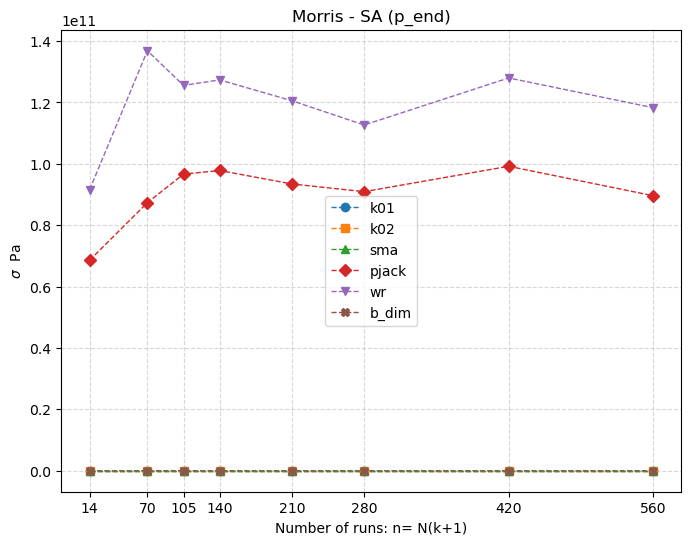

In [ ]:
phase = 'p_end'  #sum_c, peak,p_end (1,2,3)
morrisp='sigma' #mu_star, sigma, mu_star_conf,mu (1,2,3,_)
N_list=n_r #[2,10,15,20,30,40,60,80]
size=(8,6)
grid=True

fig=graph_morris_a(results_scaled,N_list, phase,morrisp,grid,size)
# ax = fig.axes[0] 
# ax.set_yscale('log')

namecomb1={'sum_c':1,
           'peak':2,
           'p_end':3,
           }
namecomb2={'mu_star':1,
           'sigma':2,
           'mu_star_conf':3}

# fig.savefig(fname=cwd/f'Morris_SA_BH10_40_6_{namecomb1[phase]}s{namecomb2[morrisp]}.pdf',  #save to potential untracked folder
#             format="pdf",
#             bbox_inches='tight',
#             pad_inches=0.05
#             ) 

fig

## V2 analysis (4 parameters)

In [22]:
names=['sf0', 'pjack', 'wr', 'L']
bounds=[[2.0926206997084548e-10,8.5e-4],
                        [3.1e6,3.6e6],
                        [0.2e6,0.5e6],
                        [0.5,20]
                        ]
problem = {'num_vars': len(names), 
        'names': names,
        'bounds': bounds}

sbounds= scal_bounds(bounds)

In [23]:
version_list=['v10','v11','v12']
results=[]
n_r=[] #runs per N parameter
for version in version_list:

    json_file= cwd/f'results_{version}/results/results_archive_{version}.jsonl'
    sample_archive= cwd/f'results_{version}/morris_samples_{version}.csv'


    Y_a = load_jdata(json_file)
    X_a = pd.read_csv(sample_archive).values 
    n_r.append(len(X_a))
    metrics = ['sum_c', 'peak', 'p_end']

    result = {}
    for m in metrics:
        Ym = get_metric_array(Y_a, m)
        
        Si = morris_analyzer.analyze(problem, X_a, Ym, num_levels=4)
        result[m] = Si
        # # Output check
        # print(f"Results for {m}: {Si['mu_star']}")
    results.append(result)


results_scaled= rescaling_morris(metrics,results,sbounds)

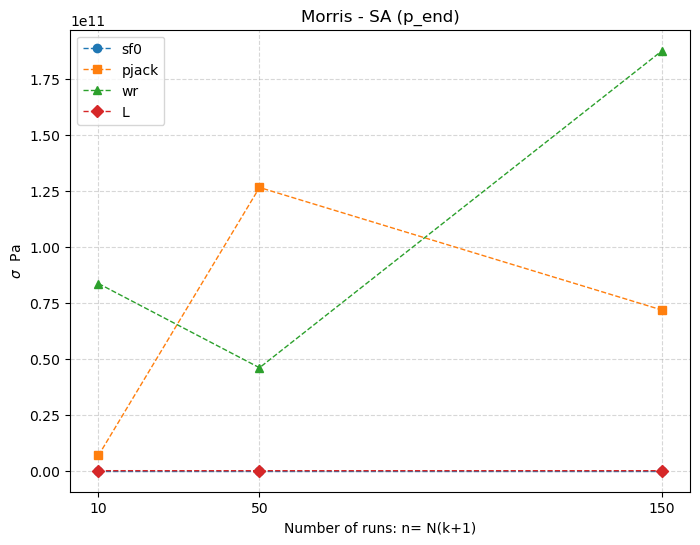

In [ ]:
phase = 'p_end'  #sum_c, peak,p_end (1,2,3)
morrisp='sigma' #mu_star, sigma, mu_star_conf,mu (1,2,3,_)
N_list=n_r #[2,10,15,20,30,40,60,80]
size=(8,6)
grid=True

fig=graph_morris_a(results_scaled,N_list, phase,morrisp,grid,size)
# ax = fig.axes[0] 
# ax.set_yscale('log')

namecomb1={'sum_c':1,
           'peak':2,
           'p_end':3,
           }
namecomb2={'mu_star':1,
           'sigma':2,
           'mu_star_conf':3}

# fig.savefig(fname=cwd/f'Morris_SA_BH10_40_6_{namecomb1[phase]}s{namecomb2[morrisp]}.pdf',  #save to potential untracked folder
#             format="pdf",
#             bbox_inches='tight',
#             pad_inches=0.05
#             ) 

fig
